# <b>세미1차_전화 해지 여부 분류
* https://dacon.io/competitions/official/236075/data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#-----------------------------------------------------------------------------------  인코딩
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

#-----------------------------------------------------------------------------------  정규화
from sklearn.preprocessing import MinMaxScaler,  RobustScaler, StandardScaler
from sklearn.pipeline import Pipeline

#-----------------------------------------------------------------------------------  모델
from sklearn.linear_model import LogisticRegression          # 선형모델
from sklearn.tree import DecisionTreeClassifier              # 트리모델
from sklearn.ensemble import RandomForestClassifier          # 배깅모델   : 데이터N,  똑같은모델N(앙상블)
from lightgbm import LGBMClassifier                          # 부스팅모델 : 데이터1,  다양한모델N(앙상블)
from xgboost import XGBClassifier

#-----------------------------------------------------------------------------------  평가
from sklearn.metrics import accuracy_score,      f1_score,  precision_score , recall_score,         roc_auc_score
from sklearn.metrics import                                 precision_recall_curve,                 roc_curve
from sklearn.metrics import classification_report,          confusion_matrix

#-----------------------------------------------------------------------------------  교차검증
from sklearn.model_selection import train_test_split,                     KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_validate,      GridSearchCV

import warnings
warnings.filterwarnings('ignore')

sns.set()

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>1. 데이터 불러오기

In [2]:
df = pd.read_csv(r"C:\IT\workspace_ptyhon\ST\train.csv")
#df_sample = pd.read_csv(r"C:\IT\workspace_ptyhon\ST\sample_submission.csv")
#df_test = pd.read_csv(r"C:\IT\workspace_ptyhon\ST\test.csv")

# <b> 2. 데이터 구조 및 구성 확인

## 2-1 데이터 크기 확인(shape)

In [3]:
df.shape

(30200, 14)

## 2-2 데이터 구조 확인(info)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30200 entries, 0 to 30199
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   ID       30200 non-null  object 
 1   가입일      30200 non-null  int64  
 2   음성사서함이용  30200 non-null  int64  
 3   주간통화시간   30200 non-null  float64
 4   주간통화횟수   30200 non-null  int64  
 5   주간통화요금   30200 non-null  float64
 6   저녁통화시간   30200 non-null  float64
 7   저녁통화횟수   30200 non-null  int64  
 8   저녁통화요금   30200 non-null  float64
 9   밤통화시간    30200 non-null  float64
 10  밤통화횟수    30200 non-null  int64  
 11  밤통화요금    30200 non-null  float64
 12  상담전화건수   30200 non-null  int64  
 13  전화해지여부   30200 non-null  int64  
dtypes: float64(6), int64(7), object(1)
memory usage: 3.2+ MB


## 2-3 결측치 확인(isnull)
* 결측치 없음

In [5]:
df.isnull().sum()

ID         0
가입일        0
음성사서함이용    0
주간통화시간     0
주간통화횟수     0
주간통화요금     0
저녁통화시간     0
저녁통화횟수     0
저녁통화요금     0
밤통화시간      0
밤통화횟수      0
밤통화요금      0
상담전화건수     0
전화해지여부     0
dtype: int64

## 2-4 피쳐확인(columns)

In [6]:
df.columns

Index(['ID', '가입일', '음성사서함이용', '주간통화시간', '주간통화횟수', '주간통화요금', '저녁통화시간',
       '저녁통화횟수', '저녁통화요금', '밤통화시간', '밤통화횟수', '밤통화요금', '상담전화건수', '전화해지여부'],
      dtype='object')

## 2-5 형태 확인(describe)

In [7]:
df.describe()

,가입일,음성사서함이용,주간통화시간,주간통화횟수,주간통화요금,저녁통화시간,저녁통화횟수,저녁통화요금,밤통화시간,밤통화횟수,밤통화요금,상담전화건수,전화해지여부
count,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000,30200.000000
mean,159.732649,12.037815,250.563457,159.175728,41.091447,263.247215,158.474536,25.394260,263.438285,157.047417,12.074648,2.288079,0.109868
std,123.752781,24.925334,84.403350,101.573057,23.179017,74.064922,102.200293,8.146126,73.778416,101.721601,9.414261,2.050746,0.312730
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,20.800000,20.000000,1.040000,0.000000,0.000000
25%,63.000000,0.000000,222.800000,88.000000,24.400000,223.700000,87.000000,22.220000,223.700000,87.000000,4.700000,2.000000,0.000000
50%,118.000000,1.000000,234.000000,117.500000,30.800000,243.000000,112.000000,23.320000,242.800000,108.000000,9.080000,2.000000,0.000000
75%,228.000000,22.000000,289.600000,223.000000,45.900000,290.300000,223.000000,28.820000,290.500000,222.000000,20.290000,2.000000,0.000000
max,2212.000000,1112.000000,481.900000,489.000000,118.600000,481.600000,489.000000,49.980000,481.800000,490.000000,44.980000,11.000000,1.000000


In [8]:
df.columns

Index(['ID', '가입일', '음성사서함이용', '주간통화시간', '주간통화횟수', '주간통화요금', '저녁통화시간',
       '저녁통화횟수', '저녁통화요금', '밤통화시간', '밤통화횟수', '밤통화요금', '상담전화건수', '전화해지여부'],
      dtype='object')

## 2-6 중복값확인(duplicated)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.head(5)

,ID,가입일,음성사서함이용,주간통화시간,주간통화횟수,주간통화요금,저녁통화시간,저녁통화횟수,저녁통화요금,밤통화시간,밤통화횟수,밤통화요금,상담전화건수,전화해지여부
0,TRAIN_00000,329,0,99.2,93,27.3,268.8,68,28.92,262.9,328,32.89,2,0
1,TRAIN_00001,2,80,323.9,323,83.7,269.4,326,32.09,322.8,209,32.32,2,0
2,TRAIN_00002,93,28,282.4,323,34.2,207.0,322,32.82,280.8,328,8.28,0,0
3,TRAIN_00003,223,1,221.4,223,25.1,233.0,61,23.90,203.8,234,9.36,0,0
4,TRAIN_00004,222,0,96.3,222,28.7,223.9,69,28.08,263.1,223,2.80,8,0


### 중복/고유값/상수 컬럼(정보 없는 변수) 탐지

In [11]:
dup_rows = df.duplicated().sum()
print("중복 행 개수:", dup_rows)

# 고유값 개수
nunique = df.nunique(dropna=False).sort_values()
display(nunique.head(30))

# 상수 컬럼/거의 상수 컬럼 후보
const_cols = nunique[nunique <= 1].index.tolist()
near_const_cols = nunique[(nunique > 1) & (nunique <= 2)].index.tolist()

print("상수 컬럼:", const_cols)
print("거의 상수(고유값 2개) 후보:", near_const_cols[:20])

중복 행 개수: 0


전화해지여부         2
상담전화건수        11
음성사서함이용       76
밤통화횟수        233
주간통화횟수       239
저녁통화횟수       241
가입일          345
주간통화요금       735
밤통화요금       1216
저녁통화요금      1840
밤통화시간       2545
저녁통화시간      2606
주간통화시간      2771
ID         30200
dtype: int64

상수 컬럼: []
거의 상수(고유값 2개) 후보: ['전화해지여부']


# 3 컬럼명 바꾸기

In [12]:
original_columns = df.columns.tolist() #원본 컬럼 백업 

# 컬럼명 바꾸기 & 도메인 지식
col_rename_map = {
    'ID': 'id',
    '전화해지여부': 'target',
    '가입일': 'tenure', # 가입기간이 짧으면 해지 가능성 높음, 장기 고객일수록 해지 가능성이 낮음
    '음성사서함이용': 'vm_count', # 음성사서함을 자주 쓰는 고객은 서비스 활용도가 높아 해지 가능성이 낮을 수 있음

    '주간통화시간': 'day_minutes', # 통화량이 적으면 서비스 활용도가 낮아 해지 가능성이 높을 수 있음
    '주간통화횟수': 'day_calls', # 통화 횟수가 적으면 서비스 사용률 낮음 → 해지 가능성 ↑
    '주간통화요금': 'day_charge', # 요금이 낮으면 서비스 활용도 낮음 → 해지 가능성 ↑ 요금이 높으면 서비스 의존도 높음→ 해지 가능성 ↓ (단, 과도한 요금은 불만 요인이 될 수도 있음)

    '저녁통화시간': 'eve_minutes', # 저녁 통화가 많으면 생활 패턴과 연결 → 충성 고객 가능성 ↑
    '저녁통화횟수': 'eve_calls', # 빈도가 적으면 해지 가능성 ↑
    '저녁통화요금': 'eve_charge', # 요금 낮으면 사용량 적음 → 해지 가능성 ↑

    '밤통화시간': 'night_minutes', # 밤 시간대 사용이 많으면, 서비스 활용도가 높아 해지 가능성 낮음
    '밤통화횟수': 'night_calls', # 낮은 빈도 → 해지 가능성 ↑
    '밤통화요금': 'night_charge', # 요금 낮으면 사용량 적음 → 해지 가능성 ↑

    '상담전화건수': 'cs_calls' #상담전화가 많을수록 해지 가능성 ↑ 불만, 문제발생, 서비스 문의
}
# 컬럼명 변환
df = df.rename(columns=col_rename_map)

print(df.columns.tolist())

['id', 'tenure', 'vm_count', 'day_minutes', 'day_calls', 'day_charge', 'eve_minutes', 'eve_calls', 'eve_charge', 'night_minutes', 'night_calls', 'night_charge', 'cs_calls', 'target']


# 4 분석 전 불필요한 id제거

In [13]:
df = df.drop(columns=['id'])

In [14]:
print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (30200, 13)


,tenure,vm_count,day_minutes,day_calls,day_charge,eve_minutes,eve_calls,eve_charge,night_minutes,night_calls,night_charge,cs_calls,target
0,329,0,99.2,93,27.3,268.8,68,28.92,262.9,328,32.89,2,0
1,2,80,323.9,323,83.7,269.4,326,32.09,322.8,209,32.32,2,0
2,93,28,282.4,323,34.2,207.0,322,32.82,280.8,328,8.28,0,0
3,223,1,221.4,223,25.1,233.0,61,23.90,203.8,234,9.36,0,0
4,222,0,96.3,222,28.7,223.9,69,28.08,263.1,223,2.80,8,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30200 entries, 0 to 30199
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tenure         30200 non-null  int64  
 1   vm_count       30200 non-null  int64  
 2   day_minutes    30200 non-null  float64
 3   day_calls      30200 non-null  int64  
 4   day_charge     30200 non-null  float64
 5   eve_minutes    30200 non-null  float64
 6   eve_calls      30200 non-null  int64  
 7   eve_charge     30200 non-null  float64
 8   night_minutes  30200 non-null  float64
 9   night_calls    30200 non-null  int64  
 10  night_charge   30200 non-null  float64
 11  cs_calls       30200 non-null  int64  
 12  target         30200 non-null  int64  
dtypes: float64(6), int64(7)
memory usage: 3.0 MB


None

# ------------------------------------------------------------------------------------------------

# <b>EDA  

### <b>타겟(churn) 분포 확인

In [15]:
print(df['target'].value_counts()) #타겟의 빈도수
print(df['target'].value_counts(normalize=True)) # 타겟의비율

target
0    26882
1     3318
Name: count, dtype: int64
target
0    0.890132
1    0.109868
Name: proportion, dtype: float64


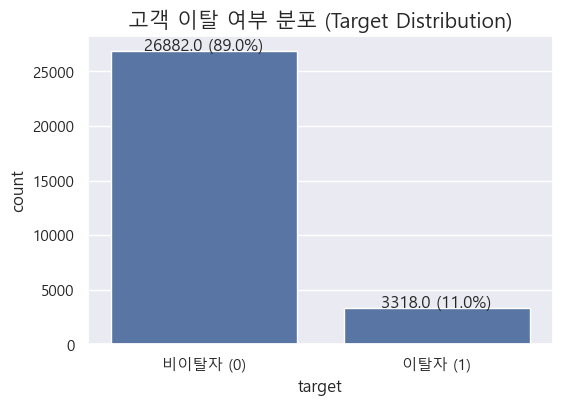

In [16]:
# sns.countplot(x='target', data=df, palette='Set2')
# plt.title('비이탈자 vs.이탈자')
# plt.show();


plt.figure(figsize=(6,4))
ax = sns.countplot(x='target', data=df)

total = len(df['target'])
for p in ax.patches: #퍼센트&건수표시로 가독성높히기
    height = p.get_height()
    ax.text(p.get_x() + p.get_width()/2., height + 3,
            f'{height} ({height/total:.1%})', ha="center")

plt.title('고객 이탈 여부 분포 (Target Distribution)', fontsize=15)
plt.xticks([0, 1], ['비이탈자 (0)', '이탈자 (1)']) 
plt.show();

### 수치형 분포(히스토그램) + 왜도/첨도 표

,feature,skew,kurtosis
1,vm_count,10.159494,378.258369
0,tenure,3.106704,39.885231
12,target,2.495178,4.226195
11,cs_calls,1.554562,2.402749
10,night_charge,1.276195,1.330879
4,day_charge,1.193922,0.024647
9,night_calls,0.808396,0.315923
6,eve_calls,0.801134,0.286689
8,night_minutes,0.782545,2.088991
5,eve_minutes,0.768130,2.088177


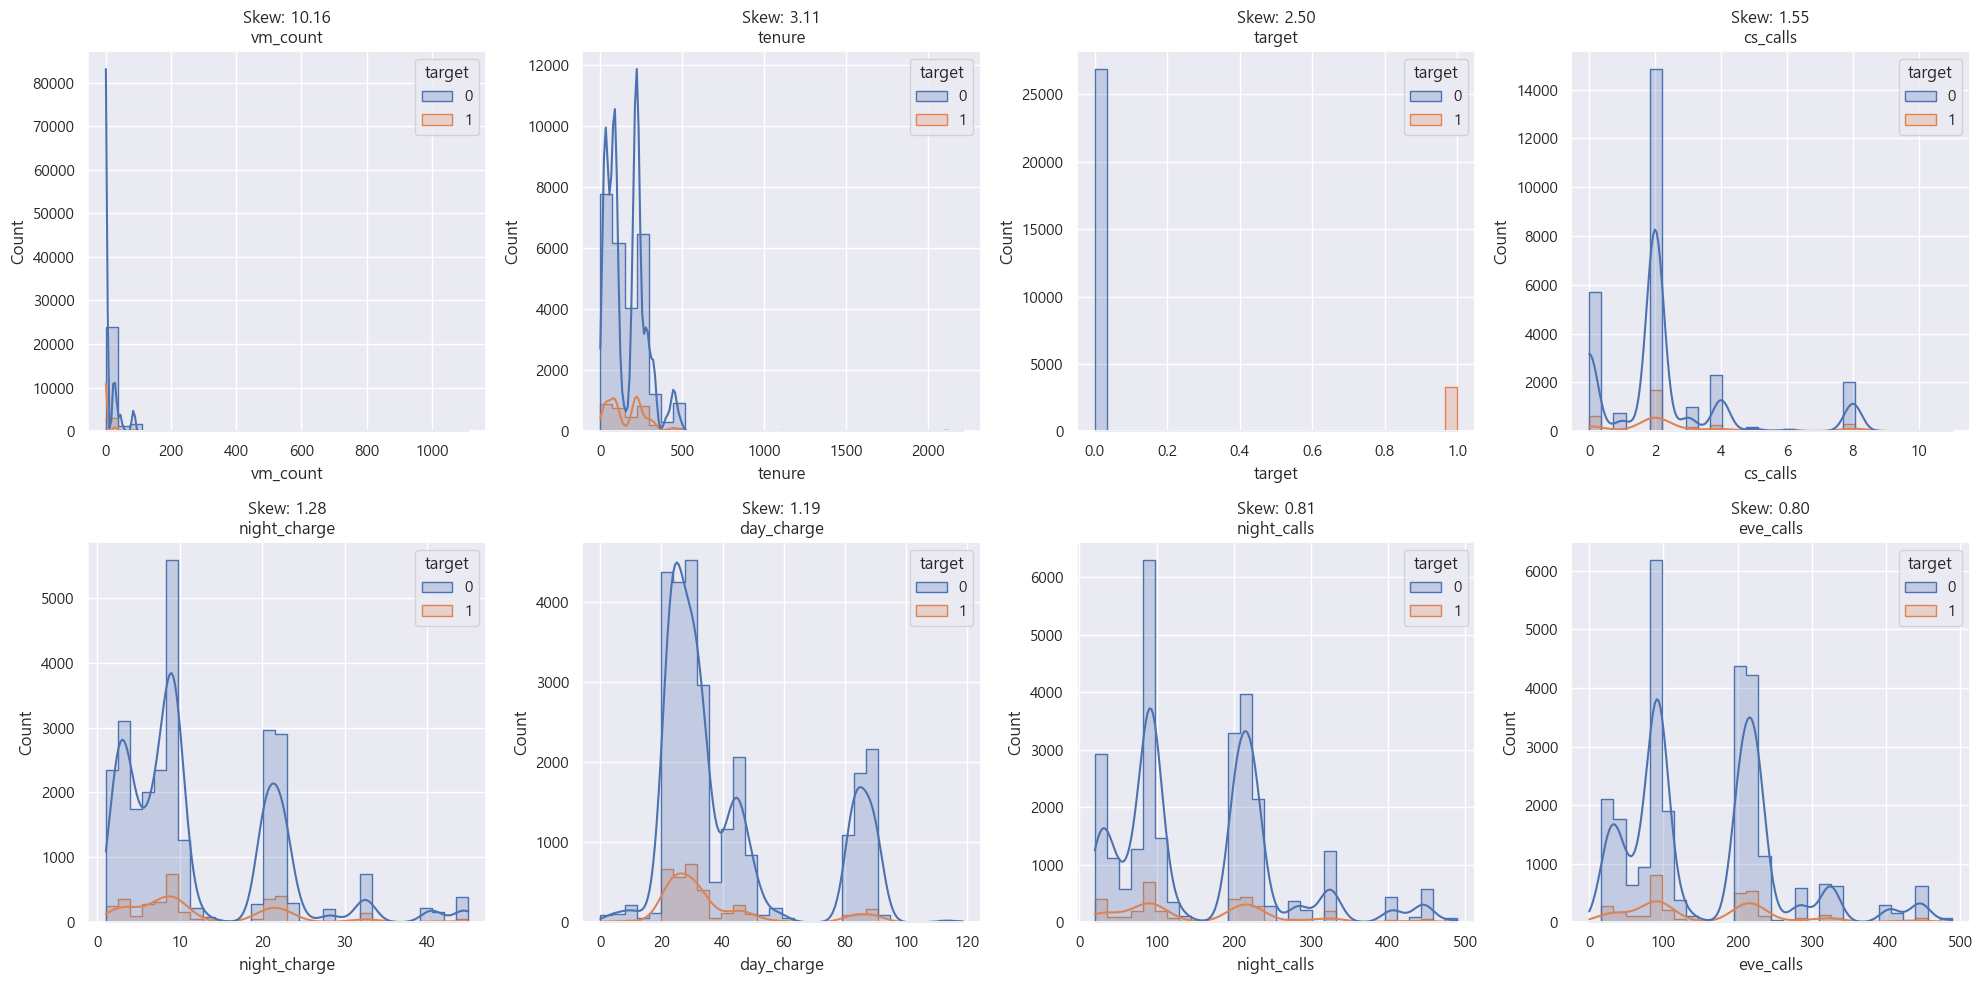

In [17]:
numeric_cols = df.select_dtypes(include=["int64","float64"]).columns.drop("churn", errors="ignore") #왜도/첨도는 수치형 변수에만 의미있어서 수치형 컬럼만 선택
skew_kurt = [] #왜도 & 첨도 계산
for c in numeric_cols:
    x = df[c].dropna()
    skew_kurt.append((c, x.skew(), x.kurtosis()))

skew_kurt_df = pd.DataFrame(skew_kurt, columns=["feature","skew","kurtosis"]).sort_values("skew", key=np.abs, ascending=False) #절대값 기준으로 왜도 기준 정렬
display(skew_kurt_df.head(20))

#  차트(그리드 배치)
top_skew = skew_kurt_df["feature"].head(8).tolist()

# 왜도 큰 상위 변수 분포 확인
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten() 

# 기존차트
# for i, c in enumerate(top_skew):
#     sns.histplot(df[c], bins=30, kde=True, ax=axes[i], color='skyblue', )
#     axes[i].set_title(f"Skew: {df[c].skew():.2f}\n{c}", fontsize=12)
#     axes[i].set_xlabel("")
#     axes[i].set_ylabel("")

# 이탈자의 분포 편향 확인가능
for i, c in enumerate(top_skew):
    sns.histplot(data=df, x=c, hue='target', bins=30, kde=True, ax=axes[i], element="step")
    axes[i].set_title(f"Skew: {df[c].skew():.2f}\n{c}", fontsize=12)
    
# 차트 보기쉽게수정한거라 신경안써도됨둥
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout();
plt.show();

<pre>
* 극단적 비대칭 변수 : vm_count, tenure
  vm_count(음성메일) : 왜도 - 매우 강한 우측 치우침 / 첨도 - 극단값이 강하게 존재, 극소수 고객이 매우 큰 값을 보유함 / 일반 연속형변수로 보기 어려워서 이산형+극단 집중형분포 / 로그 변환, 구간화필요성
  tenure (가입 기간) : 첨도 - 장기고객 일부가 극단값형성 / 장기 유지 고객군 존재, 고객 충성도 분포가 비대칭 / churn에서는 중요한 신호일 수 있어서 제거보다는 구간화 권장

* 전체 분포 특
  : 대부분 우측 비대칭, 통화 시간변수는 상대적으로 안정적, 정규분포가정이 부적합

 * 대부분의 통화량/요금 관련 피쳐들이 양의 왜도를 보임 => 소수의 헤비유저가 높은 이용량을 차지하는 통신데이터의 특징
 * 왜도가 2.0넘어가는 변수들은 모델 안정성을 위해 로그변환 또는 robsutScaler적용검토 -> 모델이라 모르겟당

## 상관/다중공선성/중복 정보 점검 (EDA 6단계)

In [18]:
# 히스토그램 수정해야함
# import matplotlib.pyplot as plt
# import seaborn as sns

# # 이미지의 상관계수 상위 항목들을 기반으로 구성
# def plot_corr_hist(df, x_col, y_col):
#     plt.figure(figsize=(10, 6))
    
#     # 2D Histogram (밀도를 히트맵 형태의 히스토그램으로 시각화)
#     plt.hist2d(df[x_col], df[y_col], bins=30, cmap='Blues')
    
#     cb = plt.colorbar()
#     cb.set_label('Counts in Bin')
    
#     plt.title(f"2D Histogram: {x_col} vs {y_col}", fontsize=15)
#     plt.xlabel(x_col)
#     plt.ylabel(y_col)
#     plt.show()

# # 1. 상관계수 0.582인 변수 쌍
# plot_corr_hist(df, 'eve_minutes', 'eve_charge')

# # 2. 상관계수 0.403인 변수 쌍
# plot_corr_hist(df, 'eve_charge', 'night_minutes')

* 이전에 배운 피어슨 방식은 두 변수가 선형관계로 변할 때만 수치가 잘 나오고 이상치 하나에 수치가 확 변하는 단점
* 지금의 자료는 이상치가 많고, 요금-시간 관계가 비선형형태라 스피어만 쓰는게 데이터의 실질적 연관성을 더 정확히 보여줌

* 히트맵해석
* 강력한 상관관계 분석 (상관계수 > 0.35)
 eve_minutes ↔ eve_charge (0.58): 저녁 시간대의 통화량과 요금이 매우 정비례함, 다만 1.0이 아니라는 것은 요금제에 따른 분당 단가 차이가 존재함
 eve_charge ↔ night_minutes (0.40): 저녁에 돈을 많이 쓰는 고객이 밤늦게까지 통화를 많이 하는 경향, '헤비 유저' 그룹의 특징
 day_minutes ↔ eve_charge / night_minutes (0.36~0.37): 특정 시간대가 아닌 '하루 종일' 통신 서비스를 활발히 이용하는 고객군이 존재

* 다중공선성(Multicollinearity) 주의 구간
  위험 징후: 상관계수가 0.58인 eve_minutes와 eve_charge는 모델이 학습할 때 중복된 신호로 착각 가능
  엔지니어링 제안: 두 변수를 각각 쓰는 것도 좋지만, charge_per_min = eve_charge / eve_minutes 같은 파생 피처를 하나로 통합하여 모델의 복잡도를 줄이고 예측력을 높이는 것이 좋다

* 타겟(target)과의 관계 (이탈 신호 포착)
  현재 데이터는 시간대별 이용량과 요금이 서로 얽혀 있는 구조, 이탈 여부와 직접적인 선형 관계를 가진 변수는 드물기에,  비선형 파생 피처들이 Recall과 Macro-F1을 올리는 결정적인 역할을 할 것.

<Figure size 1200x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Spearman Correlation Heatmap (numeric)')

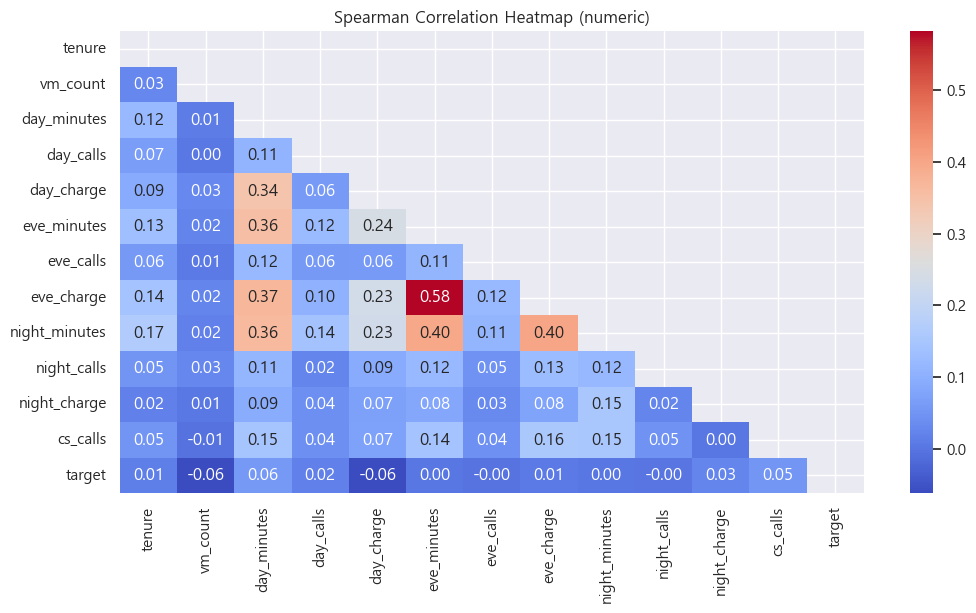

eve_minutes    eve_charge       0.582299
eve_charge     night_minutes    0.403082
eve_minutes    night_minutes    0.398314
day_minutes    eve_charge       0.368581
               night_minutes    0.362238
               eve_minutes      0.355500
               day_charge       0.342345
day_charge     eve_minutes      0.244269
               eve_charge       0.233863
               night_minutes    0.231133
tenure         night_minutes    0.166343
eve_charge     cs_calls         0.156312
night_minutes  night_charge     0.152996
               cs_calls         0.150583
day_minutes    cs_calls         0.146141
tenure         eve_charge       0.144204
eve_minutes    cs_calls         0.143594
day_calls      night_minutes    0.141643
tenure         eve_minutes      0.132276
eve_charge     night_calls      0.125515
dtype: float64

In [19]:
corr = df[numeric_cols].corr(method="spearman")  # 스피어만 상관계수 계산 순위 기반 상관계수 비정규분포랑 이상치에 덜 민감하다
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 6))
sns.heatmap(corr, annot=True, fmt='.2f', mask=mask, cmap='coolwarm')
plt.title("Spearman Correlation Heatmap (numeric)")
plt.show();  # 히트맵 => eve_charge-day_charrge : 하루 시간대별 요금 / night_minutes-night_charge : 사용시간과 요금

# 상관 높은 쌍 TOP 20 추출(중복 제거)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_pairs = upper.abs().stack().sort_values(ascending=False).head(20)
display(high_pairs)

## 이상치(IQR) 비율 산출 + Boxplot

,feature,outlier_rate(IQR)
4,day_charge,0.186126
2,day_minutes,0.158146
7,eve_charge,0.134934
5,eve_minutes,0.113808
8,night_minutes,0.113079
1,vm_count,0.059371
6,eve_calls,0.027417
9,night_calls,0.026589
3,day_calls,0.026490
10,night_charge,0.014106


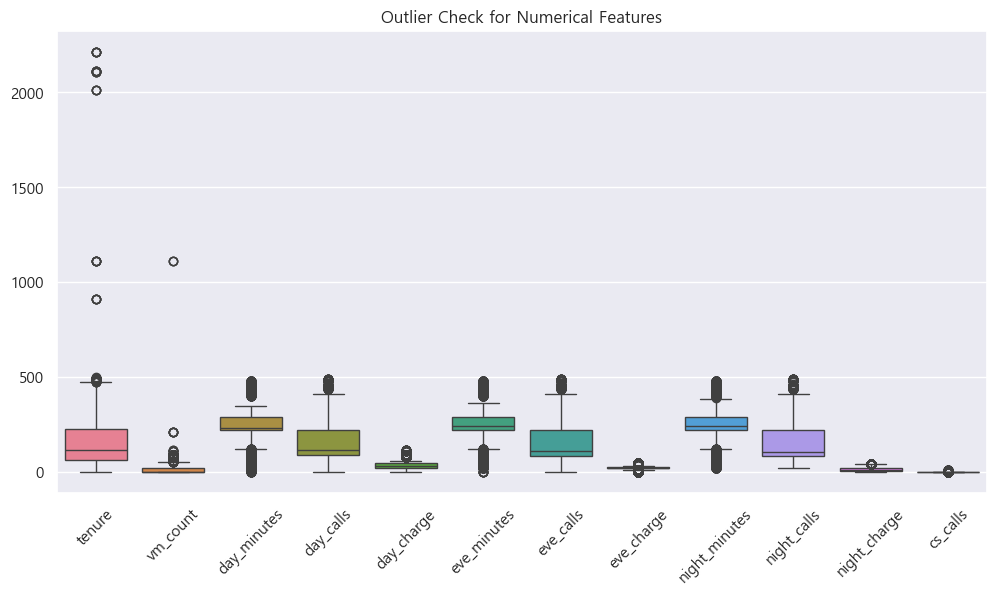

In [20]:
# 이상치 비율계산
out_tbl = [] #수치형 변수 반복
for c in numeric_cols:
    x = df[c].dropna() #해당 변수 결측치 제거
    q1, q3 = x.quantile(0.25), x.quantile(0.75)
    iqr = q3 - q1
    if iqr == 0:
        out_rate = 0.0 # iqr 0이면 이상치 없음
    else:
        lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr # 이상치 범위 설정
        out_rate = ((x < lo) | (x > hi)).mean() # 이상치 비율 계산
    out_tbl.append((c, out_rate))

out_df = pd.DataFrame(out_tbl, columns=["feature","outlier_rate(IQR)"]).sort_values("outlier_rate(IQR)", ascending=False) # 이상치 많은 변수대로 정렬
display(out_df.head(20))

# 이상치 Boxplot 시각화
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.drop(columns=[ 'target']))
plt.xticks(rotation=45)
plt.title('Outlier Check for Numerical Features')
plt.show();

* 이상치 = 이탈신호(recall)의 핵심으로 단순 에러가 아닌 이탈징후(ex.상담을 비정상적으로 많이함) -> 이상치 삭제보다는 파생피쳐를 만들어 강조하는 것이 좋음
* 변수마다 데이터의 범위가 제각각임 = 트리모델에는 지장없으나 Macro-F1의 안정성을 위해 전처리 파이프라인에서 스케일링이 필수적
* 만약 cs_calls 관련 이상치 비율이 높다면 상담전화 관련 새로만든 피쳐가 모델에서 중요한 역할을 하는지 방증하는 지표가 됨

<pre>
* 이상치 해석
  : 통화 시간 및 요금 변수에서 상대적으로 높은 이상치의 비율이 보였으나, 데이터 오류가 아닌 과다 사용 고객임
    트리 기반 모델에서는 이상치의 영향이 제한적이라 단순 제거보다는 로그변환이나 구간화 전략이 적절
  이상치 비율 해석
  : 통화시간과 요금변수에서 이상치 비율 높음, 특히 주간사용량에서 제일 높음, 요금과 사용시간은 선형이라 동일패턴이 반복됨
    데이터 왜곡이라기보다는 비대칭 분포의 특성 = 제거대상은 아님
  

## 타겟 중심 EDA
*  KDE(분포 차이) + boxplot(중앙/이상치 차이)

,feature,mean_diff(1-0),cohens_d,abs_d
4,day_charge,-5.262819,-0.243873,0.243873
1,vm_count,-5.000058,-0.224698,0.224698
11,cs_calls,0.374528,0.174399,0.174399
2,day_minutes,8.090089,0.097824,0.097824
10,night_charge,0.436891,0.046752,0.046752
3,day_calls,3.564272,0.035314,0.035314
0,tenure,2.646751,0.021664,0.021664
6,eve_calls,-1.397518,-0.013750,0.013750
9,night_calls,-1.015193,-0.010002,0.010002
8,night_minutes,-0.677588,-0.009537,0.009537


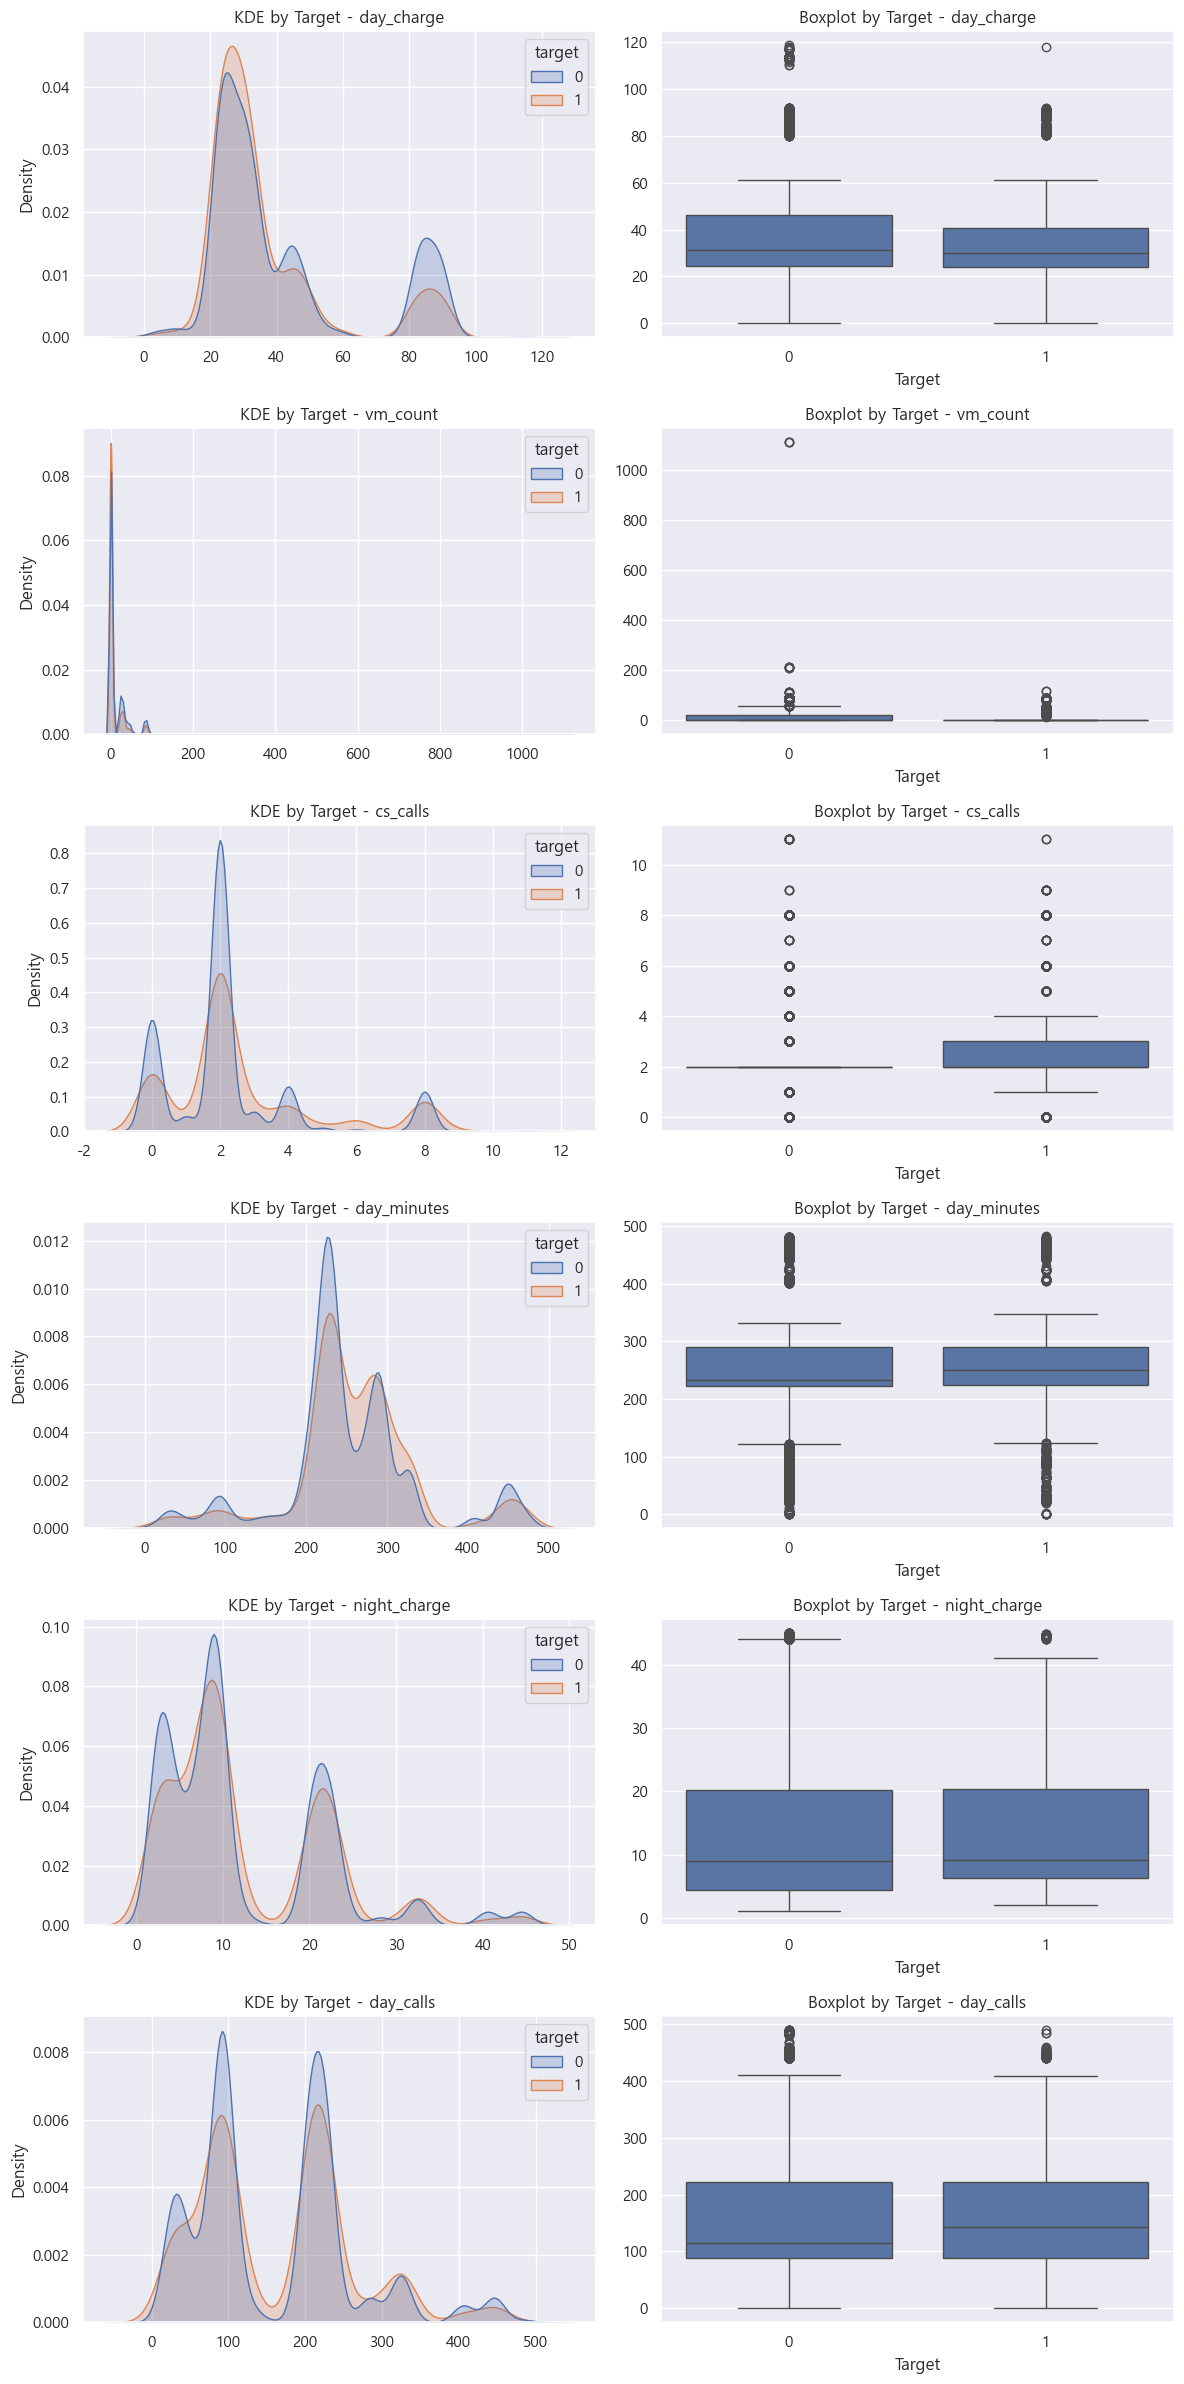

In [21]:
# 타깃에 따라 수치형 변수들이 얼마나 차이나는지 확인
def cohens_d(a, b): #두 그룹간 효과크기 계산함수, 값이 클수록 그룹간 차이가 큼, 효과크기는 이탈자와 비이탈자의 실질적 차이를 정규화된 수치로 보여줌
    a = a.dropna(); b = b.dropna() #결측제거
    if len(a) < 2 or len(b) < 2:
        return np.nan #표본이 2개미만이면 분산 계산 불가로 결측처리
    s = np.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2)
    if s == 0:
        return 0.0 #분산이 0이면 차이없음
    return (b.mean() - a.mean()) / s  # (target=1 - target=0)

rows = []
for c in numeric_cols:
    g0 = df.loc[df["target"]==0, c]
    g1 = df.loc[df["target"]==1, c] #타겟분리
    diff = g1.mean() - g0.mean() # 평균 차이 계산
    d = cohens_d(g0, g1)
    rows.append((c, diff, d, abs(d))) # abs_d가 높은 상위 변수들의 KED에서 두 색의 그래프가 많이 떨어져있을수록 그 피쳐는 recall을 직접적으로 올리는 변수가 됨

num_target_df = pd.DataFrame(rows, columns=["feature","mean_diff(1-0)","cohens_d","abs_d"]) #데이터프레임 생성&정렬
num_target_df = num_target_df.sort_values("abs_d", ascending=False) #타겟과 가장 관계강한 변수 찾기
display(num_target_df.head(20))

# 상위 변수 시각화
top = num_target_df["feature"].head(6).tolist()

fig, axes = plt.subplots(nrows=6, ncols=2, figsize=(12, 24))

for i, c in enumerate(top):
    
    # KDE Plot - 확률밀도 분포비교 - 겹치는 부분이 작을수록 변수와 타깃 간 관계가 강함
    sns.kdeplot(
        data=df, x=c, hue="target",
        fill=True, common_norm=False,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f"KDE by Target - {c}", fontsize=12)
    axes[i, 0].set_xlabel("")
    axes[i, 0].set_ylabel("Density")
    
    # Box Plot - 중앙값, 사분위수, 이상치 등으로 그룹 간 차이확인
    sns.boxplot(
        data=df, x="target", y=c,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f"Boxplot by Target - {c}", fontsize=12)
    axes[i, 1].set_xlabel("Target")
    axes[i, 1].set_ylabel("")

plt.tight_layout();
plt.show();

In [22]:
#df["target"].value_counts(normalize=True) # 타겟 불균형 -> smote, class_weight, f1, roc-auc

## 범주형: 타겟별 비율(Churn rate) + 막대그래프

,feature,top_categories,top_churn_rate
0,cs_calls,"[9, 6, 7, 5, 3]","[0.8333333333333334, 0.5517241379310345, 0.5384615384615384, 0.24786324786324787, 0.16440677966101694]"


<Figure size 800x500 with 0 Axes>

<Axes: xlabel='cs_calls', ylabel='target'>

Text(0.5, 1.0, 'Top categories churn rate: cs_calls')

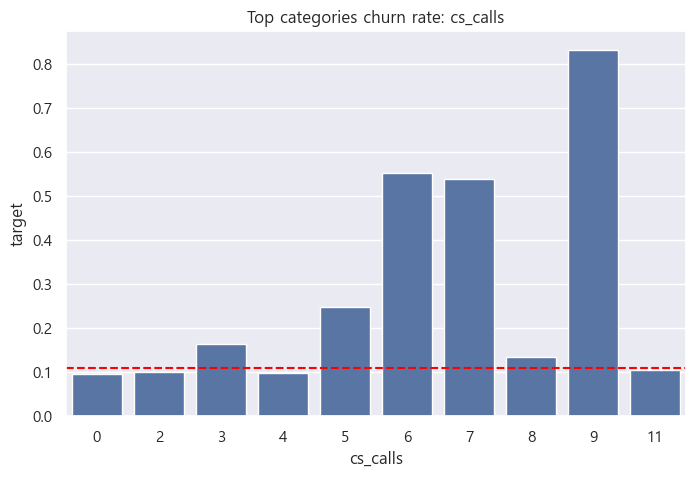

In [23]:
cat_cols = [col for col in df.columns if df[col].nunique() < 20]  # nunique() < 20 :수치형 데이터라도 범주형처럼 해석될 수 있는 변수
# col for col in df.columns if ~ : 조건에 맞는 컬럼만 담기
# df[col].nunique() < 20 : 데이터 타입이 정수나 실수여도 그룹가능
cat_cols = [c for c in cat_cols if c not in ["target", "ID"]] # target과 ID는 제외

cat_results = [] #상위 이탈률 테이블
for c in cat_cols:
    # 카테고리별 타겟=1 비율
    rate = df.groupby(c)["target"].mean().sort_values(ascending=False)
    cat_results.append((c, rate.index[:5].tolist(), rate.values[:5].tolist()))
display(pd.DataFrame(cat_results, columns=["feature","top_categories","top_churn_rate"]).head(20)) # 어떤 집단이 가장 위험한가 

# 특정 범주형 하나 선택 시각화 예시(상위 10개만)
if len(cat_cols) > 0:
    c = cat_cols[0]
    churn_rate = df.groupby(c)["target"].mean().sort_values(ascending=False).head(10).reset_index()
    
    plt.figure(figsize=(8,5))
    sns.barplot(data=churn_rate, x=c, y="target") #이탈의 임계점 시각화
    
    avg_churn = df["target"].mean() # 평균선
    plt.axhline(avg_churn, color='red', linestyle='--', label=f'Avg Churn ({avg_churn:.2f})')
    
    plt.title(f"Top categories churn rate: {c}")
    plt.show(); #그래프보면 고객센터랑 5번 이상 전화한 고객은 탈주함

## 피쳐 간 관계분석

In [24]:
df.columns

Index(['tenure', 'vm_count', 'day_minutes', 'day_calls', 'day_charge',
       'eve_minutes', 'eve_calls', 'eve_charge', 'night_minutes',
       'night_calls', 'night_charge', 'cs_calls', 'target'],
      dtype='object')

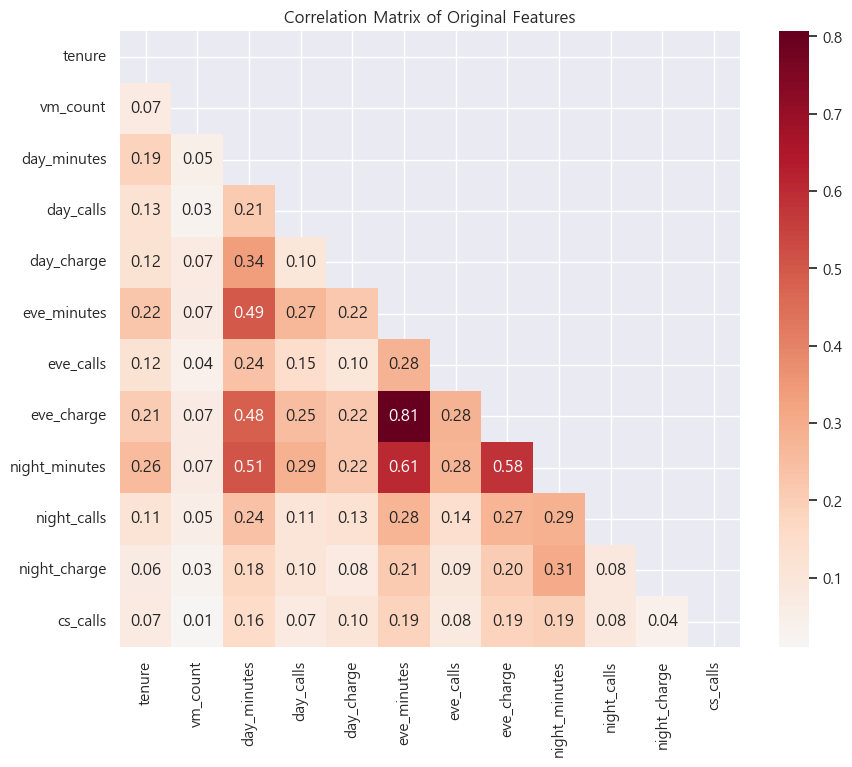

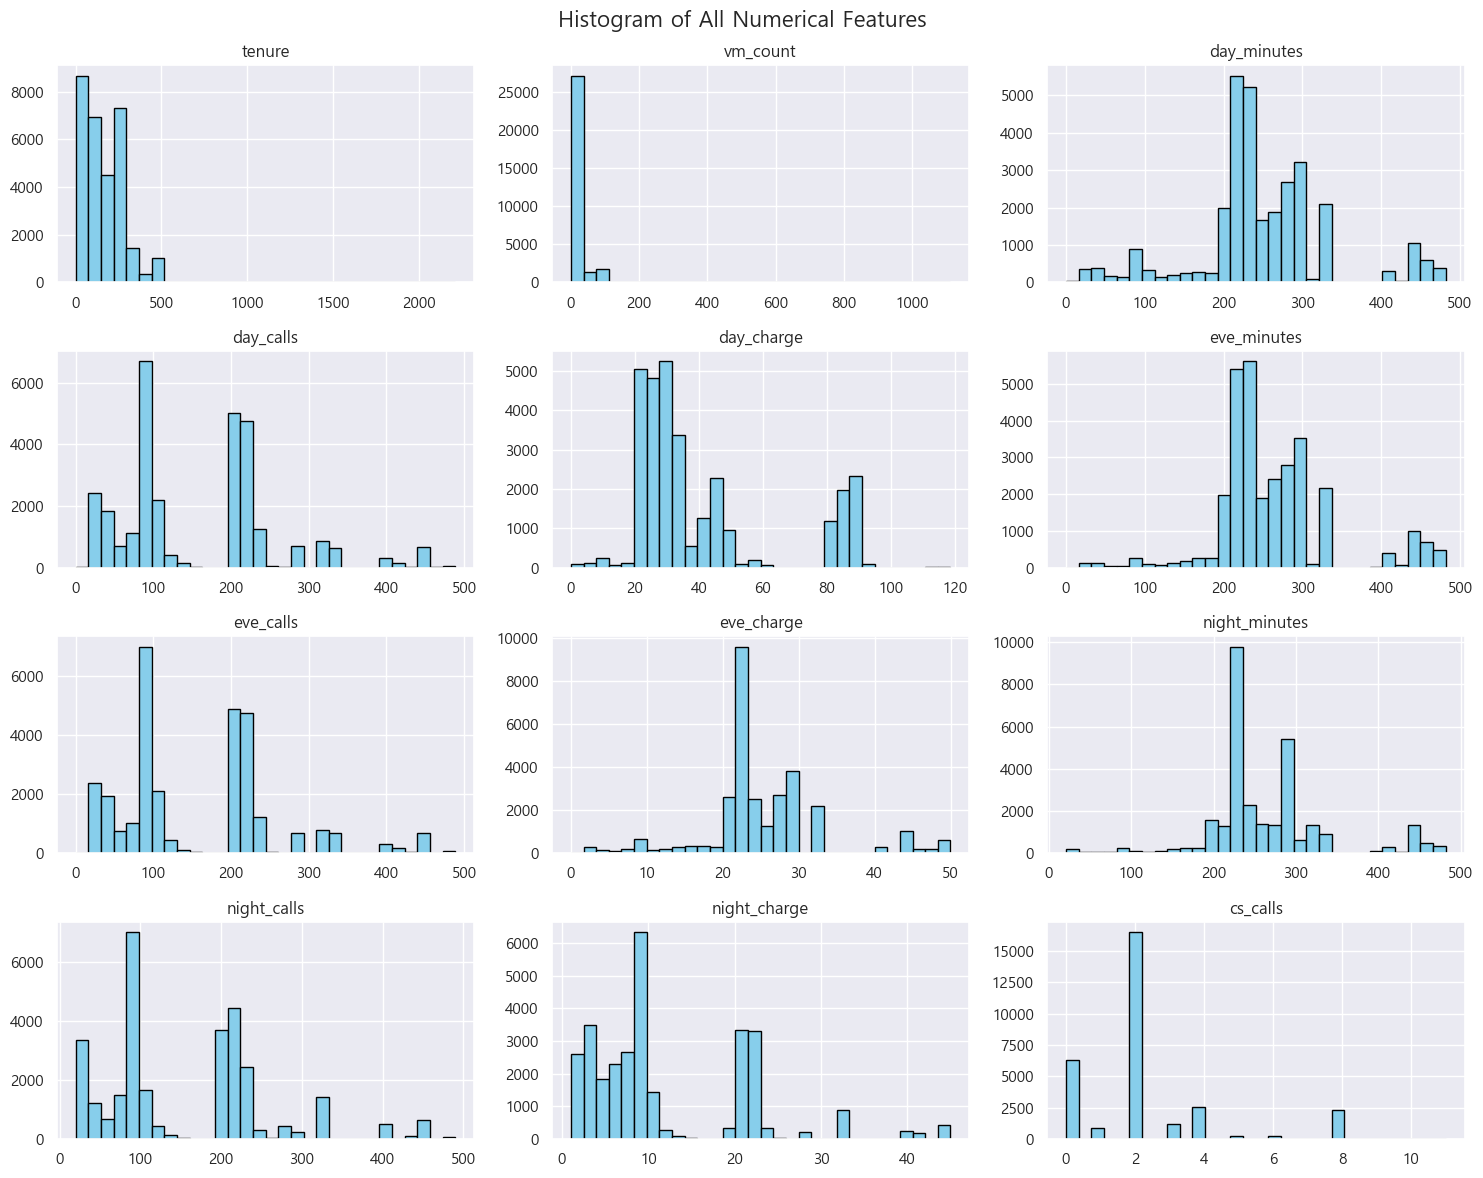

In [25]:
# 1-1. 수치형 변수들 간의 상관계수 히트맵 (다중공선성 확인용)
plt.figure(figsize=(10, 8))
corr = df.drop(columns=['target']).corr()   # 타겟 변수 제외, 수치형 변수들 간 피어슨 상관계수 계산
mask = np.triu(np.ones_like(corr, dtype=bool)) 
sns.heatmap(corr, annot=True, fmt=".2f", mask=mask, cmap='RdBu_r', center=0)
plt.title("Correlation Matrix of Original Features")
plt.show();

# 1-2. 전체 수치형 변수 히스토그램 (데이터의 분포 모양 확인)
df.drop(columns=['target']).hist(figsize=(15, 12), bins=30, color='skyblue', edgecolor='black') # 각 수치형 변수들의 분포를 개별 히스토그램으로 시각화, 구간30으로 분포확인, 왜도 이상치 파악
plt.suptitle("Histogram of All Numerical Features", fontsize=16)
plt.tight_layout()
plt.show();

<pre>
저녁 시간대 변수(eve)에서 강한 다중공선성 -> 존재요금은 사용 시간에 선형적으로 종속
고객 이탈 예측 모델링 이전 단계에서 변수 간 관계 파악 및 다중공선성(Multicollinearity) 확인을 목적

* eve_minutes – eve_charge (r = 0.81) = 매우 강한 양의 상관관계 -> 요금(charge)은 사용 시간(minutes)에 비례해 계산되는 구조로 해석, 모델링 시 둘 중 하나 제거 권장
* night_minutes – eve_minutes (r = 0.61)/night_minutes – eve_charge (r = 0.58)/day_minutes – night_minutes (r = 0.51) -> 사용량 기반 공통 패턴 존재 가능성

전체 수치형 변수 위에도 비슷하게 있긴한디 얘는 전체, 위에는 상위 몇개만
분포 형태, 왜도(skewness), 이상치(outlier), 데이터 집중 구간을 파악하여 모델링 전 전처리 방향을 결정

* 가입기간(tenure) : 우측 왜도 / 신규 가입 고객 비율이 높음,장기 고객은 상대적으로 적음 / 로그 변환은 크게 필요하지 않음 구간화(Short / Mid / Long-term) 고려 가능
* 음성메일 사용량 (vm_count) : 0 근처에 데이터 집중, 극단적 우측 왜도 대부분 사용하지 않음 / 음성메일 서비스 이용 고객이 매우 적음 사실상 이진 변수 성격 / 0 / 1(사용 여부)로 변환 고려 또는 범주형처리
* 통화 시간 (minutes 계열) : 비교적 정규분포 / 고객 사용량이 평균 중심으로 분포, 극단적 이상치는 많지 않음 / 표준화(StandardScaler) 권장
* 통화 요금 (charge 계열) : 시간계열이랑 유사, 선형 관계 / 요금은 사용 시간에 비례, 독립적 정보는 적음 / minutes와 중복 -> 하나 제거 고려
* 통화 횟수 (calls 계열) : 여러 구간에 데이터 집중, 완전 정규분포는 아님 / 고객 그룹이 나뉘어 있을 가능성 / 그대로 사용 가능, 필요시 구간화도
* 고객센터 연락 횟수 (cs_calls) : 강한 우측 왜도, 소수고객(0~3집중) / 높은 cs_calls는 불만 가능성 / 3회 이상 여부 이진 변수 생성 고려
  

## 타겟-피쳐의 상관관계

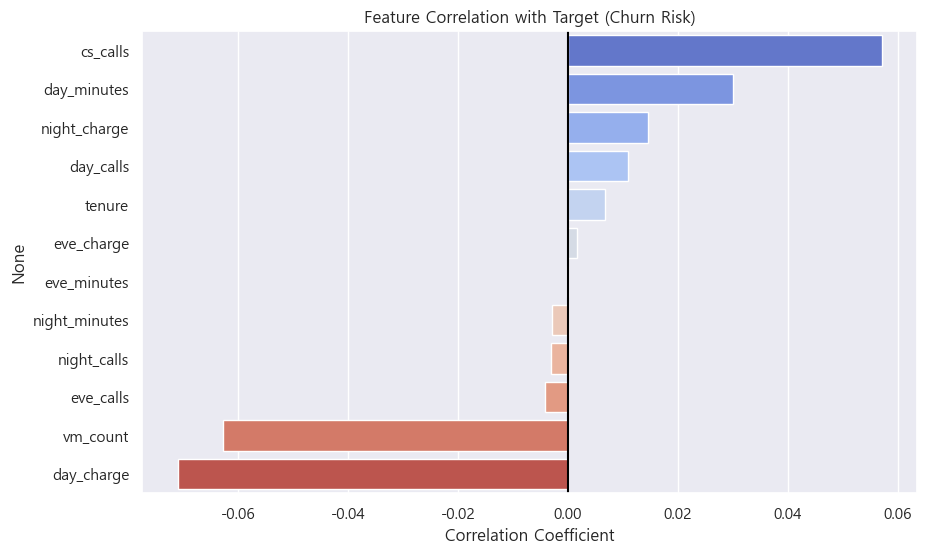

In [26]:
# 타겟과의 상관관계만 추출하여 정렬
target_corr = df.corr()['target'].sort_values(ascending=False).drop('target')

plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.values, y=target_corr.index, palette='coolwarm')
plt.axvline(0, color='black', linestyle='-')
plt.title("Feature Correlation with Target (Churn Risk)")
plt.xlabel("Correlation Coefficient")
plt.show();

<pre>
* 파란색 : 양의 상관관계(이탈 증가 요인)
  cs_calls (고객센터 연락 횟수) -> 핵심 이탈 예측 변수
  day_minutes : 사용시간 많을수록 이탈 증가 경향 -> 요금 부담 증가 가능성, 고사용 고객의 가격 민감도 존재 가능
  night_charge : 야간 요금 -> 요금관련요소가 영향 있음
  day_calls : 활동량 많은 고객은 오히려 이탈 가능성 높음 -> 사실 노이해 왜? 사용량 많으면 좋은거아닌가?

* 빨간색 : 음의 상관관계(이탈 감소 요인)
  day_charge : 요금이 높을수록 이탈 감소 -> 프리미엄 고객, 높은 요금제 고객=충성도 높을수있음
  vm_count : 음성메일 사용고객은 이탈 가능성 낮음 -> 부가서비스 이용 고객은 유지가능성 높다

총평 = 고객센터 이용 횟수는 가장 강력한 이탈 신호
    요금 및 사용량 변수는 복합적 영향
    단순 선형 상관은 전반적으로 약함
    비선형 모델 기반 접근이 적절

## 가설 & 가설검증

 * 상담전화건수가 많을수록 해지 확률이 높다

In [27]:
# import scipy.stats as stats

# # 통계 검정 (비모수 검정: Mann-Whitney U test)
# # 상담전화 건수는 정규분포를 따르지 않으므로 t-test보다 Mann-Whitney가 적합
# g0 = df.loc[df['target'] == 0, 'cs_calls']
# g1 = df.loc[df['target'] == 1, 'cs_calls']
# u_stat, p_val = stats.mannwhitneyu(g0, g1)

# # 상담건수 구간화(Binning) 후 해지율 계산
# df['cs_group'] = pd.cut(df['cs_calls'], bins=[-1, 0, 2, 4, 10], labels=['0회', '1-2회', '3-4회', '5회 이상'])
# cs_churn_rate = df.groupby('cs_group')['target'].mean().reset_index()

# # 시각화
# fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# # Boxplot (그룹별 분포 차이)
# sns.boxplot(x='target', y='cs_calls', data=df, ax=ax[0], palette='Set2')
# ax[0].set_title(f'cs_calls Distribution by Target\n(P-value: {p_val:.4f})')

# # 구간별 해지율 (임계점 확인)
# sns.barplot(x='cs_group', y='target', data=cs_churn_rate, ax=ax[1], palette='Reds')
# avg_rate = df['target'].mean()
# ax[1].axhline(avg_rate, color='blue', linestyle='--', label=f'Avg Churn ({avg_rate:.2f})')
# ax[1].set_title('Churn Rate by cs_calls Group')
# ax[1].legend()

# plt.tight_layout();
# plt.show();

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30200 entries, 0 to 30199
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   tenure         30200 non-null  int64  
 1   vm_count       30200 non-null  int64  
 2   day_minutes    30200 non-null  float64
 3   day_calls      30200 non-null  int64  
 4   day_charge     30200 non-null  float64
 5   eve_minutes    30200 non-null  float64
 6   eve_calls      30200 non-null  int64  
 7   eve_charge     30200 non-null  float64
 8   night_minutes  30200 non-null  float64
 9   night_calls    30200 non-null  int64  
 10  night_charge   30200 non-null  float64
 11  cs_calls       30200 non-null  int64  
 12  target         30200 non-null  int64  
dtypes: float64(6), int64(7)
memory usage: 3.0 MB


 # ------------------------------------------------------------------------------------

# 1차 검증

In [29]:
def my_val(df):
    # 1) 타겟(정답) 벡터 y를 만든다: df에서 'target' 컬럼만 뽑음
    y = df['target']

    # 2) 입력 피처(설명변수) X를 만든다: target 컬럼을 제외한 나머지 컬럼들
    X = df.drop('target', axis=1)



    # 3) 학습/검증 데이터로 분리한다
    #    - test_size=0.2 : 전체의 20%를 검증용(X20,y20)으로 사용
    #    - random_state=42 : 매번 같은 분할이 나오게 고정(재현성)
    #    - stratify=y : 클래스 비율을 train/valid에 최대한 동일하게 맞춤(분류에서 중요)
    X80, X20, y80, y20 = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
        )



    # 4) 비교할 모델들을 리스트로 준비한다
    #    - RandomForest / XGBoost / LightGBM 3개 모델
    model_list = [
        RandomForestClassifier(random_state=42),
        XGBClassifier(random_state=42),
        LGBMClassifier(random_state=42, verbosity=-1)
    ]



    # 5) 모델을 하나씩 꺼내서 학습 -> 예측 -> 평가를 반복한다
    for model in model_list:

        # 5-1) 현재 모델 이름 출력 (리스트가 아니라 'model'의 클래스명!)
        print(f"\n{model.__class__.__name__} --------------------")

        # 5-2) 학습: train 데이터(X80,y80)로 모델을 fit
        model.fit(X80, y80)

        # 5-3) 예측: valid 데이터(X20)에 대해 클래스를 예측
        pred = model.predict(X20)

        # 5-4) 정확도(Accuracy) 계산: 전체 중 맞춘 비율
        accuracy = accuracy_score(y20, pred)

        # 5-5) 다중분류 precision/recall/f1은 average를 명시해야 안전하다
        #      macro: 각 클래스를 동일 가중치로 평균(불균형 데이터에서 유용)
        precision = precision_score(y20, pred, average='macro', zero_division=0)
        recall    = recall_score(y20, pred, average='macro', zero_division=0)
        f1        = f1_score(y20, pred, average='macro', zero_division=0)

        # 5-6) 한 줄 요약 출력
        print(f"accuracy : {accuracy:.4f}\t macro-f1 : {f1:.4f}\t recall : {recall:.4f}\t precision : {precision:.4f}")

        # 5-7) 분류 리포트 출력(클래스별 precision/recall/f1/support)
        cr = classification_report(y20, pred, zero_division=0)
        print(cr)

        # 5-8) 혼동행렬(confusion matrix)
        #      labels를 고정값으로 두면 데이터에 없는 라벨이 섞일 수 있어
        #      실제 y에 존재하는 라벨만 사용하도록 만든다
        
        labels = sorted(y.unique())
        cm = confusion_matrix(y20, pred, labels=labels)
        cm_df = pd.DataFrame(cm, index=labels, columns=labels)
        print(cm_df)

In [30]:
my_val(df)


RandomForestClassifier --------------------
accuracy : 0.9144	 macro-f1 : 0.7094	 recall : 0.6622	 precision : 0.8330
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5376
           1       0.74      0.34      0.47       664

    accuracy                           0.91      6040
   macro avg       0.83      0.66      0.71      6040
weighted avg       0.90      0.91      0.90      6040

      0    1
0  5298   78
1   439  225

XGBClassifier --------------------
accuracy : 0.9089	 macro-f1 : 0.6719	 recall : 0.6281	 precision : 0.8259
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5376
           1       0.74      0.27      0.39       664

    accuracy                           0.91      6040
   macro avg       0.83      0.63      0.67      6040
weighted avg       0.90      0.91      0.89      6040

      0    1
0  5312   64
1   486  178

LGBMClassifier --------------------
ac

 # ----------------------------------------------------------------------------------------------------------------------

# 파생피쳐 

In [31]:
df.columns

Index(['tenure', 'vm_count', 'day_minutes', 'day_calls', 'day_charge',
       'eve_minutes', 'eve_calls', 'eve_charge', 'night_minutes',
       'night_calls', 'night_charge', 'cs_calls', 'target'],
      dtype='object')

In [32]:
df.columns

Index(['tenure', 'vm_count', 'day_minutes', 'day_calls', 'day_charge',
       'eve_minutes', 'eve_calls', 'eve_charge', 'night_minutes',
       'night_calls', 'night_charge', 'cs_calls', 'target'],
      dtype='object')

In [33]:
df['target'].value_counts(normalize=True) # 타겟비율........ 모델에서 class_weight쓰는거 제미띠니가 추천해줌요..

target
0    0.890132
1    0.109868
Name: proportion, dtype: float64

In [34]:
df.head(3)

,tenure,vm_count,day_minutes,day_calls,day_charge,eve_minutes,eve_calls,eve_charge,night_minutes,night_calls,night_charge,cs_calls,target
0,329,0,99.2,93,27.3,268.8,68,28.92,262.9,328,32.89,2,0
1,2,80,323.9,323,83.7,269.4,326,32.09,322.8,209,32.32,2,0
2,93,28,282.4,323,34.2,207.0,322,32.82,280.8,328,8.28,0,0


In [35]:
# # 1 전체 통화 횟수
df['total_calls'] = (df['day_calls'] + df['eve_calls'] + df['night_calls'])

# # 2 전체 통화 시간
df['total_minutes'] = (df['day_minutes'] + df['eve_minutes'] + df['night_minutes'])

# #-- 기본 : 사용량 감소 고객 탐지 목적--

# # 5️ 상담전화 비율 : 사용량은 적은데 불만 많은 고객                              #-----핵심 : recall에 직접적 기여
df['cs_ratio'] = df['cs_calls'] / (df['total_calls'] + 1)
# # 상담전화가 5회 이상히면 위험군표시 --EDA랑 결과기준 5는 맞는데 f1점수 넘 안나와서 3으로 바꿈
df['high_cs_flag'] = (df['cs_calls'] >= 3).astype(int)

# # 6️ 가입기간 대비 상담전화 : 가입 초기 불만 폭증 고객 탐지  - 9번이랑 중복이라 막음
df['cs_per_tenure'] = df['cs_calls'] / (df['tenure'] + 1)

# # 7️ 시간대 사용 편중도 (가장 많이 쓰는 시간대 비율) : 특정 시간대만 쓰는 불안정 고객 탐지 = 해지 위험신호로 활용
df['max_time_ratio'] = df[  ['day_minutes', 'eve_minutes', 'night_minutes']].max(axis=1) / (df['total_minutes'] + 1)

# # 8️ 저사용 고객 여부 (이진화) : 위험군을 명확히 구분 =>  사용량 급감 고객 감지 recall도움
df['low_usage_flag'] = (df['total_minutes'] < df['total_minutes'].median()).astype(int)
threshold = df['total_minutes'].quantile(0.6)

# # 평균 통화시간 : 해지 직전 고객은 짧은 통화 증가패턴이 일어날수있음?
df['avg_call_duration'] = df['total_minutes'] / (df['total_calls'] + 1)


In [36]:
# # # 1 전체 통화 횟수
# #df['total_calls'] = (df['day_calls'] + df['eve_calls'] + df['night_calls'])

# # # 2 전체 통화 시간
# df['total_minutes'] = (df['day_minutes'] + df['eve_minutes'] + df['night_minutes'])

# # # 3️ 전체 요금
# #df['total_charge'] = ( df['day_charge'] +  df['eve_charge'] +  df['night_charge'])

# # #-- 기본 : 사용량 감소 고객 탐지 목적--

# # # 4️ 분당 요금 (요금 일관성 확인)
# # # # #df['charge_per_min'] = df['total_charge'] / (df['total_minutes'] + 1)

# # # 5️ 상담전화 비율 : 사용량은 적은데 불만 많은 고객                              #-----핵심 : recall에 직접적 기여
# df['cs_ratio'] = df['cs_calls'] / (df['total_calls'] + 1)
# # # 상담전화가 5회 이상히면 위험군표시 --EDA랑 결과기준 5는 맞는데 f1점수 넘 안나와서 3으로 바꿈
# df['high_cs_flag'] = (df['cs_calls'] >= 3).astype(int)

# # # 6️ 가입기간 대비 상담전화 : 가입 초기 불만 폭증 고객 탐지  - 9번이랑 중복이라 막음
# df['cs_per_tenure'] = df['cs_calls'] / (df['tenure'] + 1)

# # # 7️ 시간대 사용 편중도 (가장 많이 쓰는 시간대 비율) : 특정 시간대만 쓰는 불안정 고객 탐지 = 해지 위험신호로 활용
# df['max_time_ratio'] = df[  ['day_minutes', 'eve_minutes', 'night_minutes']].max(axis=1) / (df['total_minutes'] + 1)
# # # 시간대 사용 균형 점수 : 균형 사용 고객은 안정적일 가능성 높음. => 충성고객보호용 = precision유지
# # df['usage_balance'] = 1 - df['max_time_ratio']

# # # 8️ 저사용 고객 여부 (이진화) : 위험군을 명확히 구분 =>  사용량 급감 고객 감지 recall도움
# df['low_usage_flag'] = (df['total_minutes'] < df['total_minutes'].median()).astype(int)
# threshold = df['total_minutes'].quantile(0.6)

# # # df['low_usage_flag'] = (
# # #     df['total_minutes'] < df['total_minutes'].median()
# # # ).astype(int)

# # # 9 상담 강도(불만 밀도) : 기간 대비 상담 빈도, 단순 상담 횟수보다 더 정밀하게 위험 고객 탐지    #---- 정밀구분 : 가입 기간 대비 상담강도계산 -> 진짜 위험고객 정밀구분 = precision안정화 도움
# # df['cs_intensity'] = df['cs_calls'] / (df['tenure'] + 1)

# # # 사용 대비 불만비율 : 사용은 거의 안하는데 상담은 많음 = 해지직전
# # df['complaint_per_usage'] = df['cs_calls'] / (df['total_minutes'] + 1)

# # #장기 고객 보호플래그 :모델이 장기 고객을 과하게 해지로 예측하는 것 방지 => 장기고객과잉탐지방지 precision안정
# # df['long_term_flag'] = (df['tenure'] > df['tenure'].median()).astype(int)

# # # 평균 통화시간 : 해지 직전 고객은 짧은 통화 증가패턴이 일어날수있음?
# df['avg_call_duration'] = df['total_minutes'] / (df['total_calls'] + 1)

# # # 시간대 분산 (사용 균형도) : 균형 사용 고객은 충성도 높을 가능성 있음
# # # df['usage_std'] = df[['day_minutes', 'eve_minutes', 'night_minutes']].std(axis=1)

# # # 사용량+상담결합위험점수 : 진짜 위험고객 -- cs_ratio랑 비슷해서 막음
# # #df['risk_score'] = (df['cs_ratio'] * df['low_usage_flag'])

# # #사용 균형도 점수
# # df['usage_balance'] = 1 - df['max_time_ratio']


In [37]:
my_val(df)


RandomForestClassifier --------------------
accuracy : 0.9146	 macro-f1 : 0.7156	 recall : 0.6695	 precision : 0.8268
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      5376
           1       0.73      0.36      0.48       664

    accuracy                           0.91      6040
   macro avg       0.83      0.67      0.72      6040
weighted avg       0.90      0.91      0.90      6040

      0    1
0  5288   88
1   428  236

XGBClassifier --------------------
accuracy : 0.9104	 macro-f1 : 0.6858	 recall : 0.6408	 precision : 0.8238
              precision    recall  f1-score   support

           0       0.92      0.99      0.95      5376
           1       0.73      0.30      0.42       664

    accuracy                           0.91      6040
   macro avg       0.82      0.64      0.69      6040
weighted avg       0.90      0.91      0.89      6040

      0    1
0  5303   73
1   468  196

LGBMClassifier --------------------
ac

* 히트맵 분석
<pre>
target과의 선형 상관 거의 없음
개별 변수 하나로 churn이 설명안됨, 강한 단일 신호가 없음 -> F1 상한존재

합계 변수와 원본 강한 상관
total_minutes 가 day/eve/night 0.80 & total_calls 0.64이상인건 합계 + 원본 같이쓰고있어서 정보중복 트리에 문제 없슴

cs_ratio / high_cs_flag 축은 의미 있음
cs_ratio ↔ high_cs_flag 0.62 & cs_per_tenure ↔ high_cs_flag 0.32 => churn신호 핵심(지금 성능유지이유)

low_usage_flag가 강한 음의 상관 
low_usage_flag ↔ total_minutes = -0.65 ->저사용군이 확실히 구분됨



<Figure size 1600x1000 with 0 Axes>

<Axes: >

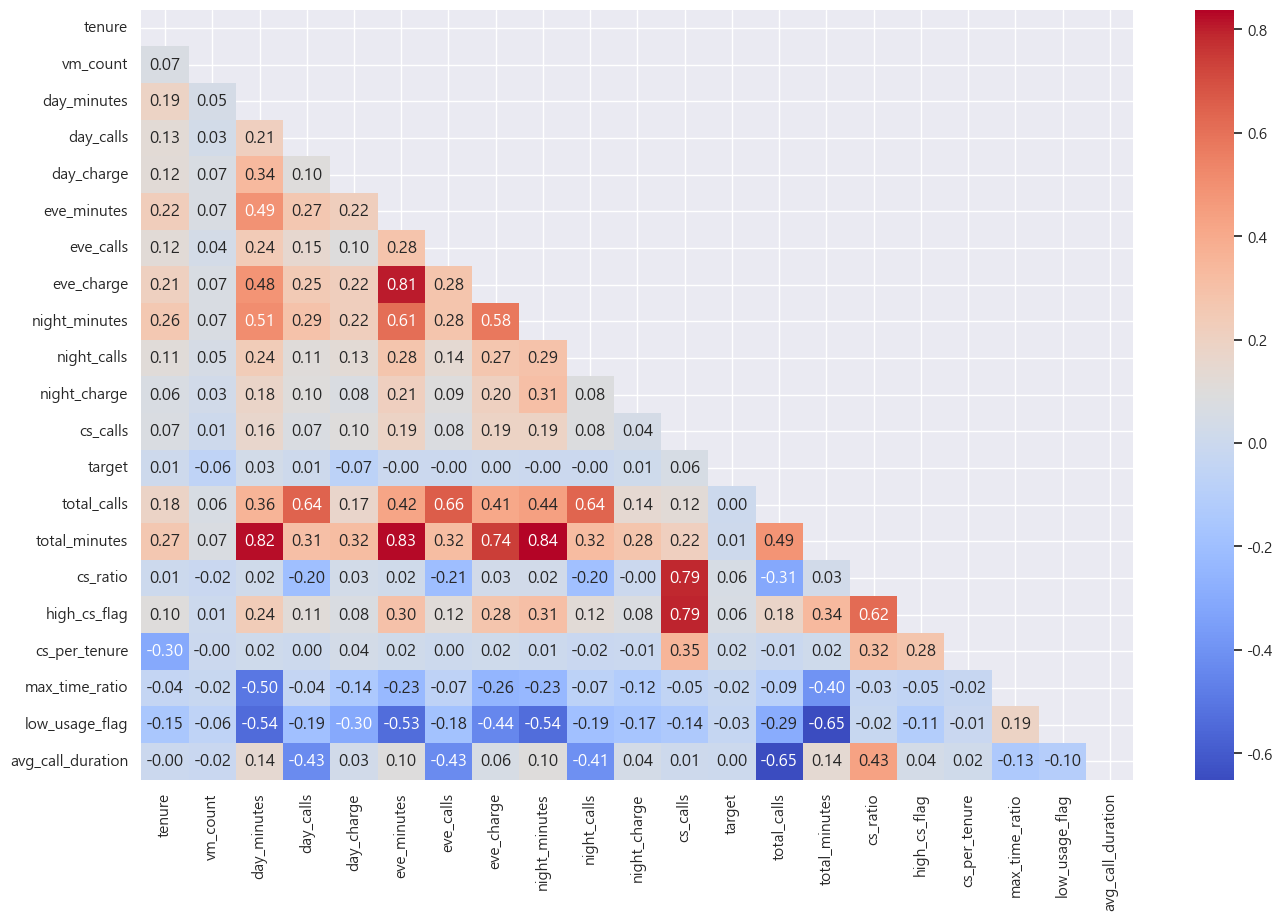

In [38]:
plt.figure(figsize=(16, 10))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt=".2f", mask=mask, cmap='coolwarm') 
plt.show()

* 파생 피처 생성 후, 고객의 상담 강도와 이용 불균형을 나타내는 변수들이 상호 보완적인 클러스터를 형성함이 확인됨. 특히 **complaint_per_usage**와 **high_cs_flag**는 단순 이용량보다 정밀한 이탈 징후를 포착하고 있어, 모델링 시 Recall과 Macro-F1의 동반 상승을 이끌 것으로 기대됨